# Latent dynamics analysis.

In [1]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import umap

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

dest = 'test1_adk'
cm = 1/2.54  # centimeters in inches
colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_dists(nele: int) -> tuple[np.ndarray, np.ndarray]:
  ji, ot = np.zeros((nele, nele)), np.zeros((nele, nele))
  with open(f"{dest}/latdyn_dists.log", 'r') as f:
    lines = f.readlines()
    for line in lines:
      words = line.split('|')
      row = int(int(words[0])/20)
      col = int(int(words[1])/20)
      ji[row, col] = float(words[2])
      ot[row, col] = float(words[3])
  return ji, ot

ji, ot = get_dists(nele=501)
ji = 1. - (ji+ji.T - np.eye(501)*ji)
ot =      (ot+ot.T - np.eye(501)*ot)

ji_coor = umap.UMAP(n_neighbors=501, n_components=2, metric='precomputed', random_state=114514).fit_transform(X=ji)
ot_coor = umap.UMAP(n_neighbors=501, n_components=2, metric='precomputed', random_state=415411).fit_transform(X=ot)

/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1

4.75 4.75
-40.85034 -23.026604 37.476074 53.140182
-17.716118 10.916287 15.29404 53.069878
0.0 0.25225052


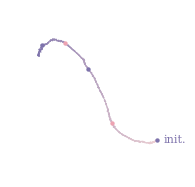

In [8]:
figspec= {'lmargin': 1/4*cm, 
          'rmargin': 1/4*cm,
          'hgap':    0  *cm,
          'hsize':  17/4*cm,
          'bmargin': 1/4*cm,
          'tmargin': 1/4*cm,
          'vgap':    0  *cm,
          'vsize':  17/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)
print(ji_coor[:, 0].min(), ji_coor[:, 0].max(), ji_coor[:, 1].min(), ji_coor[:, 1].max())
print(ot_coor[:, 0].min(), ot_coor[:, 0].max(), ot_coor[:, 1].min(), ot_coor[:, 1].max())
print(ot[0, :].min(), ot[0, :].max())

cmap = LinearSegmentedColormap.from_list('two_tone', ['#F9D9D8', '#7E73AC'])

fig, axes = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
# Plot JI.
axes.plot   (ji_coor[:, 0], ji_coor[:, 1], lw=0.25,    c='gray', zorder=-999)
axes.scatter(ji_coor[:, 0], ji_coor[:, 1], lw=0., s=1, c=ot[0, :], cmap=cmap, vmin=0., vmax=0.25)
axes.scatter(ji_coor[0, 0], ji_coor[0, 1], lw=0., s=10, c=colors[2])
axes.text(ji_coor[0, 0]+1, ji_coor[0, 1], r'init.', color=colors[2], ha='left',  va='center')

axes.scatter(ji_coor[2840//20, 0], ji_coor[2840//20, 1], lw=0., s=10, c=colors[1]) # ; axes.text(ji_coor[2840//20, 0]+1, ji_coor[2840//20, 1]+1, r'$\mathbf{b}$', color=colors[1], ha='left',  va='center')
axes.scatter(ji_coor[7440//20, 0], ji_coor[7440//20, 1], lw=0., s=10, c=colors[1]) # ; axes.text(ji_coor[7440//20, 0]+1, ji_coor[7440//20, 1]+1, r'$\mathbf{d}$', color=colors[1], ha='left',  va='center')
axes.scatter(ji_coor[5560//20, 0], ji_coor[5560//20, 1], lw=0., s=10, c=colors[2]) # ; axes.text(ji_coor[5560//20, 0]+1, ji_coor[5560//20, 1]+1, r'$\mathbf{c}$', color=colors[2], ha='left',  va='center')
axes.scatter(ji_coor[8900//20, 0], ji_coor[8900//20, 1], lw=0., s=10, c=colors[2]) # ; axes.text(ji_coor[8900//20, 0]-1, ji_coor[8900//20, 1]+1, r'$\mathbf{e}$', color=colors[2], ha='right',  va='center')

axes.set(xlim=(-45, -20), ylim=(32.5, 57.5), xticks=[], yticks=[])
axes.minorticks_off()
axes.spines[['top', 'bottom', 'left', 'right']].set_visible(False)

plt.savefig(f'./zfigures/fig_latdyn_adk_umap.jpg', dpi=300)

1.7499999999999998 2.25


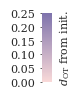

In [4]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 2/4*cm,
          'hgap':    0  *cm,
          'hsize':   1/4*cm,
          'bmargin': 1/4*cm,
          'tmargin': 1/4*cm,
          'vgap':    0  *cm,
          'vsize':  7/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

cmap = LinearSegmentedColormap.from_list('two_tone', ['#F9D9D8', '#7E73AC'])
norm = plt.Normalize(vmin=0., vmax=.25)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=axes, orientation='vertical')
cbar.ax.set_yticks([0., 0.05, .10, .15, .20, .25])
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.tick_params(axis='y', direction='out', length=1.5, width=.5, labelsize=8)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)
cbar.set_label(r'$d_\text{OT}$ from init.')

plt.savefig(f'./zfigures/fig_latdyn_adk_umap.cbar.jpg', dpi=300)

15.0 6.999999999999999
0.41095364 0.0
0.25225052 0.0


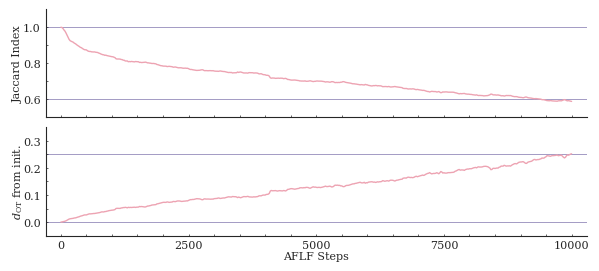

In [5]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':   55/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1/4*cm,
          'vgap':    1/4*cm,
          'vsize':   11/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*1 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)
print(np.max(ji[0, :]), np.min(ji[0, :]))
print(np.max(ot[0, :]), np.min(ot[0, :]))

fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

axes[0].axhline(y=.6, color=colors[2], ls='-', lw=0.5, zorder=0)
axes[0].axhline(y=1., color=colors[2], ls='-', lw=0.5, zorder=0)
axes[0].plot(np.arange(0, 10001, 20), 1.-ji[0, :], ls='-', lw=1., c=colors[1])
axes[0].set(ylim=(0.5, 1.1), 
            yticks=(.6, .7, .8, .9, 1.,),
            yticklabels=(.6, '', .8, '', 1.),
            xlim=(-300, 10300), 
            xticks=(   0,  500, 1000, 1500, 2000, 
                    2500, 3000, 3500, 4000, 4500, 
                    5000, 5500, 6000, 6500, 7000, 
                    7500, 8000, 8500, 9000, 9500, 10000), 
            xticklabels=(   0, '', '', '', '', 
                          2500, '', '', '', '', 
                          5000, '', '', '', '', 
                          7500, '', '', '', '', 10000), )
axes[0].set_ylabel(r'Jaccard Index', fontsize=8, va='center')
axes[0].minorticks_off()
axes[0].spines[['top','right']].set_visible(False)
axes[0].tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)

axes[1].axhline(y= .25, color=colors[2], ls='-', lw=0.5, zorder=0)
axes[1].axhline(y=0.  , color=colors[2], ls='-', lw=0.5, zorder=0)
axes[1].plot(np.arange(0, 10001, 20), ot[0, :], ls='-', lw=1., c=colors[1])
axes[1].set(ylim=(-0.05, .35), 
            yticks=(0., .05, .10, .15, .20, .25, .30),
            yticklabels=(0., '', .1, '', .2, '', .3),
            xlim=(-300, 10300), 
            xticks=(   0,  500, 1000, 1500, 2000, 
                    2500, 3000, 3500, 4000, 4500, 
                    5000, 5500, 6000, 6500, 7000, 
                    7500, 8000, 8500, 9000, 9500, 10000), 
            xticklabels=(   0, '', '', '', '', 
                          2500, '', '', '', '', 
                          5000, '', '', '', '', 
                          7500, '', '', '', '', 10000), )
axes[1].set_ylabel(r'$d_\text{OT}$ from init.',   fontsize=8, va='center')
axes[1].set_xlabel(r'AFLF Steps', fontsize=8, va='center')
axes[1].minorticks_off()
axes[1].spines[['top','right']].set_visible(False)
axes[1].tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
plt.savefig(f'./zfigures/fig_latdyn_adk_dists.jpg', dpi=300)